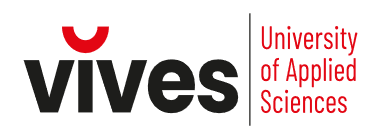<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **K NEAREST NEIGHBORS: EXERCISES**

In this topic about K Nearest Neighbors (KNN), we primarily focus on **classification**, and therefore, we can perform the same exercises as the ones we did in the topic on linear classification, where we apply KNN in this notebook.

However, KNN is a **non-linear** classifier, making it much more sensitive to **overfitting**. We will try to prevent this by tuning the hyperparameter using a validation set or cross-validation.

But before we solve the exercises from linear classification with KNN, we will first implement the KNN algorithm ourselves for both classification and regression. This will make it clear that KNN is a **lazy learner**, which means that there is actually no training phase.

## Your own KNN class

In this exercise, you will implement an intuitive implementation of the K-Nearest Neighbors algorithm. Essentially, the goal is to implement a simplified version of Scikit-Learn's `KNeighborsClassifier`.

1. Define a `KNN` class with a constructor that takes the following hyperparameters as input:

  - The number of neighbors (`K`)
  - The `distance` metric (which should default to Euclidean distance, but allow other functions such as Manhattan distance to be passed for computing the distance between data points).

  Your class should include the following methods:

  - `fit(X, y)`: Trains the model using the provided dataset.
  - `predict(X)`: Predicts the class of new data points.
  - `score(X, y)`: Computes the model's accuracy.

  The `fit` and `score` methods take both `X` (features) and `y` (labels) as input, while predict only takes `X`.

2. Test your class on the `'aliens.csv'` dataset:

  - Determine the accuracy for `K=3`,
  - Create a confusion matrix
  - Calculate precision, recall, and F1-score
  
  Don't use Scikit-Learn functions to evaluate the model. Apply your own implementation!

3. Finally, create the following new data points, predict their labels, and visualize the result:

  - An alien who is silent and doesn't speak
  - An alien who says: `"Crack dunk crack dunk crack dunk!"`

4. Repeat steps 2 and 3 using Scikit-Learn's `KNeighborsClassifier`. Do you get the same result?

### Solution

In [1]:
# 1. implement class KNN

import numpy as np
from scipy.stats import mode

class KNN:

    def __init__(self, k=1, distance=None):
        self.k = k
        self.distance = distance if distance is not None else lambda X, x: np.sqrt(np.sum(np.square(X - x), axis=1))
        self._X = None
        self._y = None

    def fit(self, X, y):
        self._X = X
        self._y = y

    def predict(self, Xnew):
        yp = []
        indices = range(self._X.shape[0])
        for x in Xnew:
            d = self.distance(self._X, x)
            sorted_indices = sorted(indices, key=lambda i: d[i]) # or use np.argsort()
            k_labels = self._y[sorted_indices[:self.k]]
            yp.append(mode(k_labels)[0])
        return np.array(yp)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [2]:
# 2a. apply class KNN to aliens.csv dataset

import pandas as pd

df = pd.read_csv("aliens.csv", sep=";")
X = df[["Crack", "Dunk"]].values.astype(float)
y = (df["Mood"] == "happy").values.astype(int)

knn = KNN(k=3)
knn.fit(X, y)
print('acc =', knn.score(X, y))

acc = 1.0


In [3]:
# 2b. implement class Metrics

class Metrics:

    def __init__(self, y, yp):
        self.y = y.astype(int)
        self.yp = yp.astype(int)
        self.n = len(y)
        # calculate TP, TN, FP, FP
        yp_is_pos = yp == 1
        yp_is_neg = yp == 0
        self.TP = np.sum(self.yp[yp_is_pos] == self.y[yp_is_pos])
        self.TN = np.sum(self.yp[yp_is_neg] == self.y[yp_is_neg])
        self.FP = np.sum(self.yp[yp_is_pos] != self.y[yp_is_pos])
        self.FN = np.sum(self.yp[yp_is_neg] != self.y[yp_is_neg])

    def confusion_matrix(self):
        cm = np.array([[self.TP, self.FN], [self.FP, self.TN]])
        cm = np.hstack((cm, cm.sum(axis=1, keepdims=True)))
        cm = np.vstack((cm, cm.sum(axis=0, keepdims=True)))
        return pd.DataFrame(data=cm,
                            columns=["Predicted Pos", "Predicted Neg", "Total"],
                            index=['Actual Pos', 'Actual Neg', 'Total'])

    def accuracy(self):
        return np.sum(self.y == self.yp) / self.n

    def recall(self):
        return self.TP / (self.TP + self.FN)

    def precision(self):
        return self.TP / (self.TP + self.FP)

    def Fbeta(self, beta):
        P = self.precision()
        R = self.recall()
        b2 = beta**2
        return (1 + b2) * P * R / (b2* P + R)

    def F1(self):
        return self.Fbeta(1)

    def sensitivity(self):
        return self.recall()

    def specificity(self):
        return self.TN / (self.TN + self.FP)

    def TNR(self):
        return self.specificity()

    def TPR(self):
        return self.sensitivity()

    def FPR(self):
        return self.FP / (self.FP + self.TN)

    def FNR(self):
        return self.FN / (self.FN + self.TP)

    def print(self, ndigits=2):
        for metric in ['accuracy', 'recall', 'precision', 'F1',
                       'sensitivity', 'specificity', 'TPR', 'TNR', 'FPR', 'FNR']:
            score = getattr(self, metric)()
            print(f"{metric} = {score:.{ndigits}f}")

In [4]:
# 2c. apply class Metrics to evaluate KNN model
yp = knn.predict(X)
metrics = Metrics(y, yp)
metrics.print()
metrics.confusion_matrix()

accuracy = 1.00
recall = 1.00
precision = 1.00
F1 = 1.00
sensitivity = 1.00
specificity = 1.00
TPR = 1.00
TNR = 1.00
FPR = 0.00
FNR = 0.00


,Predicted Pos,Predicted Neg,Total
Actual Pos,4,0,4
Actual Neg,0,4,4
Total,4,4,8


In [5]:
# 3. predict label for new aliens

# silent alien
print('Silent:', knn.predict(np.array([[0, 0]])).item())

# talking alien (3x crack and 3x dunk)
print('Talking:', knn.predict(np.array([[3, 3]])).item())

Silent: 0
Talking: 1


In [6]:
# 4a. sklearn: training

from sklearn.neighbors import KNeighborsClassifier

sklearn_knn = KNeighborsClassifier(n_neighbors=knn.k)
print("K =", sklearn_knn.n_neighbors)
sklearn_knn.fit(X, y)
print('acc =', sklearn_knn.score(X, y))

K = 3
acc = 1.0


In [7]:
# 4b: sklearn: evaluation

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

yp = sklearn_knn.predict(X)
print('acc =', accuracy_score(y, yp))
print('recall =', recall_score(y, yp))
print('precision =', precision_score(y, yp))
print('F1 =', f1_score(y, yp))
print('confusion matrix:')
print(confusion_matrix(y, yp))

acc = 1.0
recall = 1.0
precision = 1.0
F1 = 1.0
confusion matrix:
[[4 0]
 [0 4]]


In [8]:
# 4c. sklearn: predict label for new aliens

# silent alien
print('Silent:', sklearn_knn.predict(np.array([[0, 0]])).item())

# talking alien (3x crack and 3x dunk)
print('Talking:', sklearn_knn.predict(np.array([[3, 3]])).item())

Silent: 0
Talking: 1


## KNN for regression

Rename your class `KNN` from the previous exercise to `KNNclassification` and also define a class `KNNregression` to solve regression problems. In case of regression, a weighted mean is calculated of the K closest targets with weights equal to the inverse of the distances.

If a neighbor has distance = 0 (i.e., the query point is identical to a training point), then that point alone determines the prediction. So, if any distance is 0, return the corresponding target value directly (i.e., skip weighting altogether). This is simple, avoids division by zero, and ensures perfect interpolation. Scikit-Learn also applies this rule.

Let both classes inherit from an abstract superclass `KNNbase`. Make sure that all common code of the two subclasses is in the superclass.

Test the class `KNNclassification` on `'aliens.csv'`.

Test class `KNNregression` on the following simple dataset:

```
X = 100 * np.expand_dims(np.arange(1, 11), axis=1)
y = 2 * X + 50
```

Also compare your `KNNregression` class with the `KNeighborsRegressor` class from Scikit-Learn.

### Solution

In [9]:
# classes

from abc import ABC, abstractmethod
import numpy as np
from scipy.stats import mode


class KNNbase(ABC):

    def __init__(self, k=1, distance=None):
        self.k = k
        self.distance = distance if distance is not None else lambda X, x: np.sqrt(np.sum(np.square(X - x), axis=1))
        self._X = None
        self._y = None

    @abstractmethod
    def _aggregate(self, k_targets, distances):
        # return yp
        pass

    def fit(self, X, y):
        self._X = X
        self._y = y.flatten()

    def predict(self, Xnew):
        yp = []
        for x in Xnew:
            d = self.distance(X, x)
            i = np.argsort(d)[:self.k]
            yp.append(self._aggregate(self._y[i], d[i]))
        return np.array(yp).flatten()

    @abstractmethod
    def score(self, X, y):
        pass

class KNNclassification(KNNbase):

    def __init__(self, k=1, distance=None):
        super().__init__(k, distance)

    def _aggregate(self, k_targets, distances):
        return mode(k_targets)[0]  # take most common label (mode) in case of classification

    def score(self, X, y):
        return np.mean(self.predict(X) == y)  # accuracy


class KNNregression(KNNbase):

    def __init__(self, k=1, distance=None):
        super().__init__(k, distance)

    def _aggregate(self, k_targets, distances):
        b = np.isclose(distances, 0)  # check if new data point coincides with training sample
        if np.any(b): return np.mean(k_targets[b])  # take mean of targets of coinciding training samples
        return np.average(k_targets, weights=1/distances)  # weighted average in case of regression

    def score(self, X, y):
        return np.mean(np.abs(self.predict(X) - y))  # MAE

In [10]:
# test classification

import pandas as pd

aliens = pd.read_csv("aliens.csv", sep=";")
X = aliens[["Crack", "Dunk"]].values.astype(float)
y = (aliens["Mood"] == "happy").values.astype(int)

knnc = KNNclassification(k=3)
knnc.fit(X, y)
print('true:', y)
print('pred:', knnc.predict(X))
print('acc =', knnc.score(X, y))

true: [0 0 0 0 1 1 1 1]
pred: [0 0 0 0 1 1 1 1]
acc = 1.0


In [11]:
# test regression

X = 100 * np.expand_dims(np.arange(1, 11), axis=1)
fnc = lambda X: 2. * X.flatten() + 50.
y = fnc(X)

knnr = KNNregression(k=2)
knnr.fit(X, y)
print('true:', y)
print('pred:', knnr.predict(X))
print('MAE =', knnr.score(X, y))

true: [ 250.  450.  650.  850. 1050. 1250. 1450. 1650. 1850. 2050.]
pred: [ 250.  450.  650.  850. 1050. 1250. 1450. 1650. 1850. 2050.]
MAE = 0.0


In [12]:
Xnew = np.array([[300], [950]])
print('true:', fnc(Xnew))
print('pred:', knnr.predict(Xnew))

true: [ 650. 1950.]
pred: [ 650. 1950.]


In [13]:
# sklearn KNN regressor
from sklearn.neighbors import KNeighborsRegressor

sklearn_knnr = KNeighborsRegressor(n_neighbors=knnr.k, weights='distance')  # set weights to distance!
print("K =", sklearn_knnr.n_neighbors)
sklearn_knnr.fit(X, y)
sklearn_knnr.predict(Xnew)

K = 2


array([ 650., 1950.])

## Spam or ham?

- Read file `'spam_dataset.csv'`. The dataset contains information about 20 emails classifying them as spam or no spam (= ham).
- Apply the KNN classifier from Scikit-Learn to predict whether an email with 8 and 9 words, respectively, is spam or ham. In case of binary classification, it is common to use an odd number of neighbors K. Test values ranging from 1 to 9 (inclusive).
- Make a scatter plot of the data. Can you explain the results?

### Solution

In [14]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [15]:
# Generate synthetic data
num_spam_words = np.concatenate([
    np.arange(10),  # Non-spam (0 label)
    np.arange(8, 18)  # Spam (1 label)
])
labels = np.array([0] * 10 + [1] * 10)

df = pd.DataFrame({'num_spam_words': num_spam_words, 'spam': labels})
df.to_csv('spam_dataset.csv', index=False)
df

,num_spam_words,spam
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,0
8,8,0
9,9,0


In [16]:
# Read dataset from csv-file into dataframe
df = pd.read_csv('spam_dataset.csv')
df.head()

,num_spam_words,spam
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [17]:
# feature and label
X = df[['num_spam_words']].values
y = df['spam'].values

In [18]:
# Train and evaluate models
Xtest = np.array([[8], [9]])
for k in range(1, 10, 2):
    print('K =', k)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    print(knn.predict(Xtest))
    print()

K = 1
[0 0]

K = 3
[0 0]

K = 5
[0 1]

K = 7
[0 1]

K = 9
[0 1]



In [19]:
y==0

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False, False])

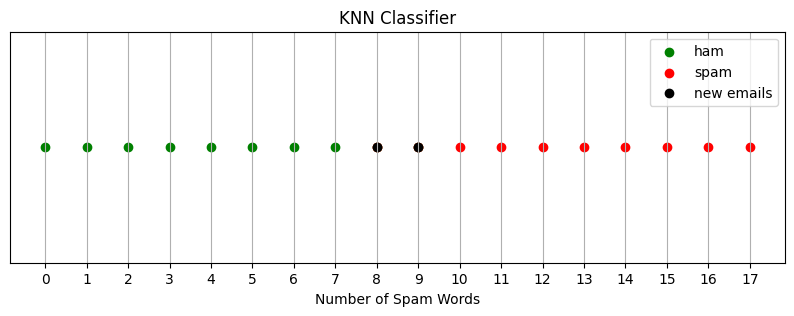

In [20]:
plt.figure(figsize=(10, 3))
plt.scatter(X[y==0], np.zeros((y==0).sum()), color='green', label='ham')
plt.scatter(X[y==1], np.zeros((y==1).sum()), color='red', label='spam')
plt.scatter(Xtest, np.zeros((2, 1)), color='black', label='new emails')
plt.xticks(np.arange(0, X.max()+1))
plt.yticks([])
plt.xlabel('Number of Spam Words')
plt.legend()
plt.title('KNN Classifier')
plt.grid();

## Churn Prediction

Customer churn refers to the percentage of customers who stop using a product or service within a certain period. In dataset `'churn_dataset.csv'`, there are three key variables:

- Monthly Charges ($): This is the amount customers pay monthly for the service, expressed in US dollars.
- Tenure (in months): This indicates how long a customer has been using the service, expressed in months.
- Label "Stayed" or "Churned": This is an indicator showing whether a customer has stayed or stopped using the service.

Perform the following tasks using this dataset:

- Read the file into a Pandas Dataframe.
- Explore the dataset.
- Find the optimal K for the KNN classifier applied to the dataset.
- Use the optimal K to predict whether a customer with 80$ monthly charges and 35 months of tenure will stay or churn.
- Make a decision boundary plot. Also add the new customer to the plot.

### Solution

In [21]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.model_selection import train_test_split

In [22]:
# use make_blobs to generate dataset
from sklearn.datasets import make_blobs

# Generate dataset with overlap
X, y = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=5, random_state=42)

# Rename features to match churn scenario
monthly_charges = X[:, 0] * 3 + 50   # Scale to represent realistic dollar amounts
tenure_months = np.abs(X[:, 1]) * 2  # Ensure positive tenure
X = np.column_stack((monthly_charges, tenure_months))

# Convert to DataFrame
df = pd.DataFrame(X, columns=['Monthly Charges ($)', 'Tenure (Months)'])
df['Customer'] = y
df['Customer'] = df['Customer'].map({0: 'Stayed', 1: 'Churned'})
df.to_csv('churn_dataset.csv', index=False)
df.head()

,Monthly Charges ($),Tenure (Months),Customer
0,35.284794,16.171982,Stayed
1,80.165405,14.484360,Churned
2,34.306666,19.137798,Stayed
3,76.250539,22.914269,Churned
4,67.331536,17.017767,Churned


In [23]:
# Read dataset into DataFrame
df = pd.read_csv('churn_dataset.csv')
df.head()

,Monthly Charges ($),Tenure (Months),Customer
0,35.284794,16.171982,Stayed
1,80.165405,14.484360,Churned
2,34.306666,19.137798,Stayed
3,76.250539,22.914269,Churned
4,67.331536,17.017767,Churned


In [24]:
# Get info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Monthly Charges ($)  100 non-null    float64
 1   Tenure (Months)      100 non-null    float64
 2   Customer             100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [25]:
# Calculate summarizing statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly Charges ($),100.0,51.507023,17.581313,3.176231,39.123023,49.180502,64.970919,92.212425
Tenure (Months),100.0,13.250410,8.881080,0.398171,6.218284,11.521522,19.519826,36.551354


In [26]:
# Scale features and encode labels
fac = np.array([100, 40])  # scaling factor
feature_names = ['Monthly Charges ($)', 'Tenure (Months)']
X = df[feature_names].values / fac
y = (df['Customer'] == 'Churned').astype(int).values

In [27]:
# Split the dataset into training and validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

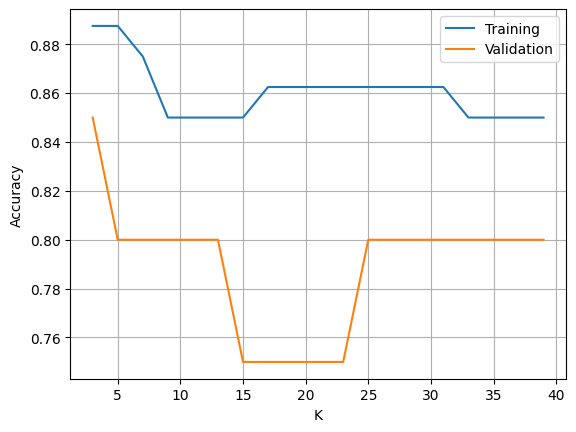

In [28]:
# Find optimal K using validation set
Krange = np.arange(3, 41, 2)
acc_train = []
acc_val = []
for K in Krange:
    knn = KNN(n_neighbors=K)
    knn.fit(X_train, y_train)
    acc_train.append(knn.score(X_train, y_train))
    acc_val.append(knn.score(X_val, y_val))
plt.plot(Krange, acc_train, label='Training')
plt.plot(Krange, acc_val, label='Validation')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend();
plt.grid();

In [29]:
# Predictions for new customer (K = 3)
customer = np.array([[80, 35]])
knn = KNN(n_neighbors=3)
knn.fit(X, y)
y_pred = knn.predict(customer / fac).item()
print(f"Prediction: {'Churned' if y_pred else 'Stayed'}")

Prediction: Churned


In [30]:
# Function to plot decision boundary
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y, resolution=0.02,
                           title='Decision Boundary', feature_names=None):
    """
    Plot the decision boundary for a 2D classification model.

    Parameters:
        model: Trained scikit-learn model with .predict method
        X: numpy array of shape (n_samples, 2), input features
        y: numpy array of shape (n_samples,), class labels
        resolution: float, grid step size
        title: str, title for the plot
        feature_names: list of str, names of the input features
    """
    # Set up color maps
    markers = ('o', 's', '^', 'x', '*')
    colors = ('red', 'blue', 'green', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Create a mesh grid
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    # Predict over the grid
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx1.shape)

    # Plot contour and training points
    plt.figure(figsize=(8, 6))
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='k')

    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    if feature_names is None:
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
    else:
        plt.xlabel(feature_names[0])
        plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend()
    plt.grid(True)

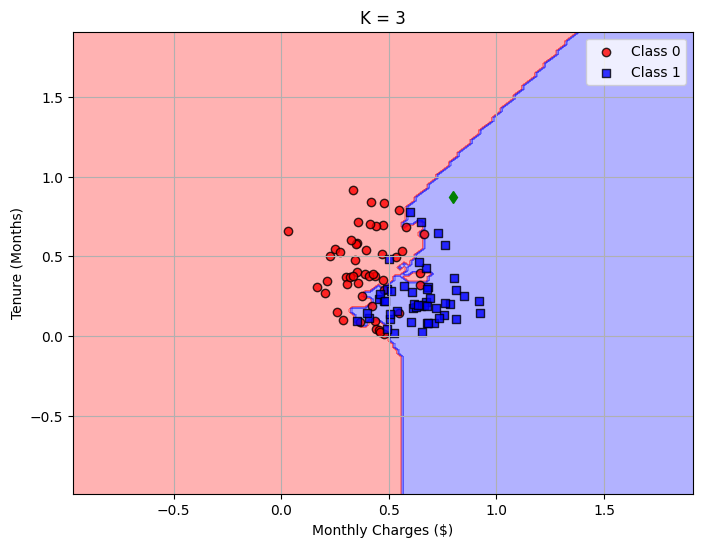

In [31]:
# decision boundary plot (+ new customer added as green diamond)
plot_decision_boundary(knn, X, y, title='K = 3', feature_names=feature_names)
plt.plot(customer[0, 0] / fac[0], customer[0, 1] / fac[1], 'gd');

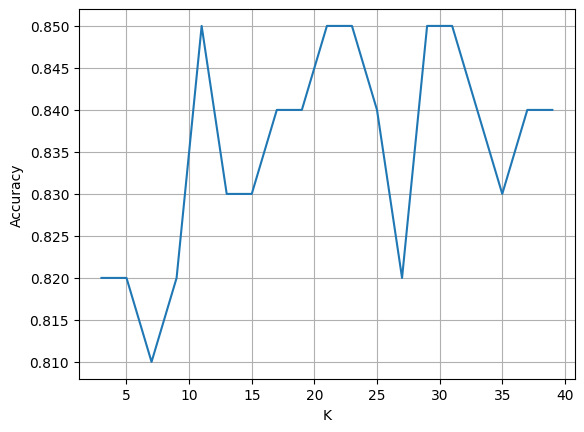

In [32]:
# decision bounary plot shows overfitting
# apply cross validation
from sklearn.model_selection import cross_val_score

acc = []
for K in Krange:
    knn = KNN(n_neighbors=K)
    acc.append(np.mean(cross_val_score(knn, X, y, cv=5)))
plt.plot(Krange, acc)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid();

In [33]:
# Predictions for new customer (K = 31)
customer = np.array([[80, 35]])
knn = KNN(n_neighbors=31)
knn.fit(X, y)
y_pred = knn.predict(customer / fac).item()
print(f"Prediction: {'Churned' if y_pred else 'Stayed'}")

Prediction: Stayed


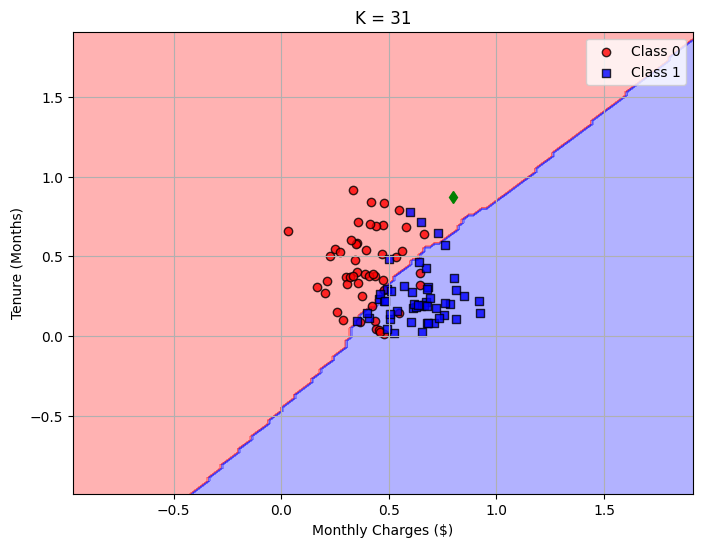

In [34]:
# decision boundary plot (+ new customer added as green diamond)
plot_decision_boundary(knn, X, y, title='K = 31', feature_names=feature_names)
plt.plot(customer[0, 0] / fac[0], customer[0, 1] / fac[1], 'gd');

**Explanation:**

First, we apply a simple hold-out validation strategy to determine the optimal value for K. In this case, K = 3 gives the highest accuracy for the validation set. However, the decision boundary plot shows an irregular boundary, which implies overfitting.

Because we are dealing with a small dataset, it is worth trying cross-validation. Here, different K values result in the highest average accuracy for the 5 cross-validation folds. **We know that smaller K values tend to overfit, while larger K values tend to underfit.** Therefore, we choose the highest value: K = 31. The decision boundary plot confirms there is no more overfitting.

## Online Advertising

Read the dataset `'Social_Network_Ads.csv'` into a Pandas `DataFrame`. You can also find it on [Kaggle](https://www.kaggle.com/datasets/dragonheir/logistic-regression).

Check the data by calculating the summarizing statistics. You can use the `DataFrame` method `describe()` for this. Create a scatter plot where you plot `Age` against `EstimatedSalary`. Color the data points green when `Purchased` is equal to 1, and red when this label is 0.

Use KNN to predict whether the following individuals will make a purchase:

- a 21-year-old woman with a salary of 25,500
- a 38-year-old man with a salary of 110,000
- a 45-year-old man with a salary of 52,000
- a 62-year-old woman with a salary of 120,000

Do not consider gender as an independent variable. Find the optimal value for K by applying cross-validation. Print your predictions nicely. Make a decision boundary plot and add the new data points to the plot.

### Solution

In [35]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.model_selection import GridSearchCV

In [36]:
# Read dataset
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [37]:
# Summary statistics
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


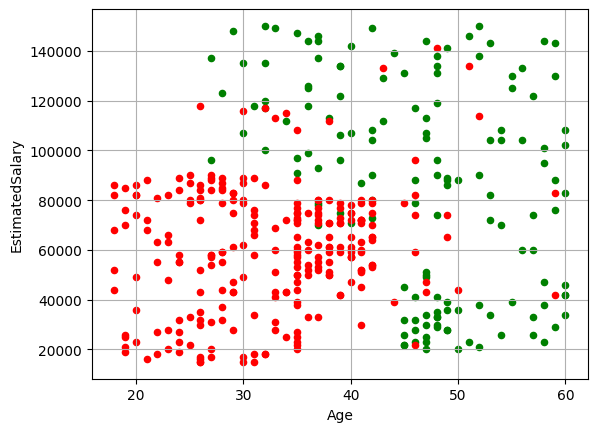

In [38]:
# Scatter plot
fig, ax = plt.subplots()
features = ['Age', 'EstimatedSalary']
label = 'Purchased'
for color, value in dict(g=1, r=0).items():
    df[df[label]==value].plot.scatter(x=features[0], y=features[1], ax=ax, color=color);
plt.grid();

In [39]:
# Features and labels
X = df[features].values.astype(float)
y = df[label].values.astype(int)

In [40]:
# Scale features
scaler = MinMaxScaler()
Xn = scaler.fit_transform(X)

In [41]:
# apply GridSearchCV, which combines grid search and cross validation

search = GridSearchCV(KNN(), {'n_neighbors': range(3, 41, 2)})  # range of K values
search.fit(Xn, y)

K_opt = search.best_params_['n_neighbors']  # optimal value for K
knn = search.best_estimator_  # best KNN model with optimal K value

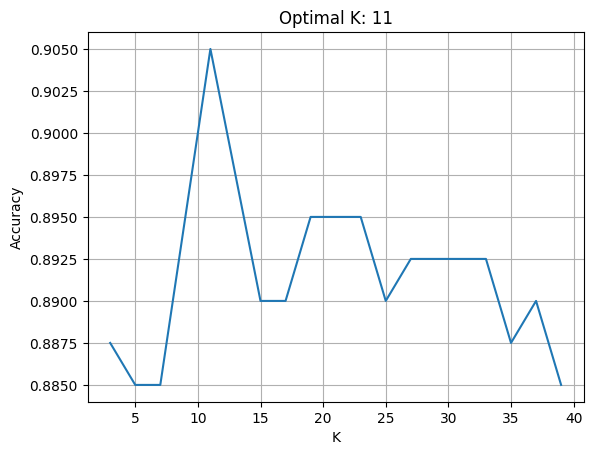

In [42]:
# plot average cross-validation score as a function of K
plt.plot(search.param_grid['n_neighbors'], search.cv_results_['mean_test_score'])
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title(f'Optimal K: {K_opt}')
plt.grid();

In [43]:
# Predict labels for new data:
# - a 21-year-old woman with a salary of 25,500
# - a 38-year-old man with a salary of 110,000
# - a 45-year-old man with a salary of 52,000
# - a 62-year-old woman with a salary of 120,000

# input (gender is not relevant)
X_new = np.array([[21, 25_500],
                  [38, 110_000],
                  [45, 52_000],
                  [62, 120_000]],
                 dtype=float)  # niet vergeten!

# Scale!
Xn_new = scaler.transform(X_new)

# predict
yp_new = knn.predict(Xn_new)
for x, yp in zip(X_new, yp_new):
    label = '' if yp else 'not '
    print(f'A {int(x[0])}-year-old person with a salary of {int(x[1])} will {label}purchase.')

A 21-year-old person with a salary of 25500 will not purchase.
A 38-year-old person with a salary of 110000 will purchase.
A 45-year-old person with a salary of 52000 will not purchase.
A 62-year-old person with a salary of 120000 will purchase.


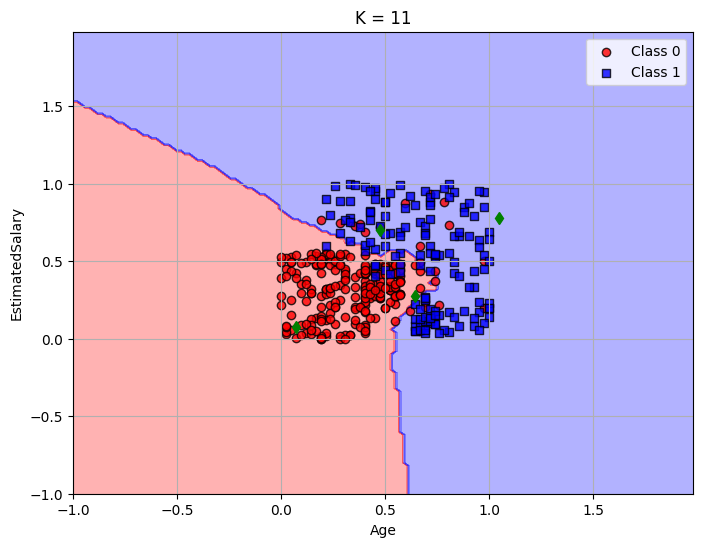

In [44]:
# Decision boundary plot (+ new data points added)
# we use function plot_decision_boundary from the previous exercise
plot_decision_boundary(knn, Xn, y, title=f'K = {K_opt}', feature_names=features)
plt.plot(Xn_new[:, 0], Xn_new[:, 1], 'gd');

## Titanic

In this exercise, you will work again with the very famous Titanic dataset. You will use a cleaned version of the dataset stored in the file `'titanic.csv'`. Remember that the goal is to predict whether someone survived the disaster based on various features.

Prepare the dataset for applying KNN. Use cross-validation to find an optimal value for the number of neighbors K. Don't forget to use a test set for the final evaluation.

### Solution

In [45]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.model_selection import train_test_split, GridSearchCV

In [46]:
# read dataset
df = pd.read_csv('titanic.csv')
df.head()

,passengerId,survived,pclass,sex,age,ticket,fare,embarked,title,deck,relatives,not_alone
0,1,0,3,male,22,A/5 21171,0,S,1,8,1,0
1,2,1,1,female,38,PC 17599,3,C,3,3,1,0
2,3,1,3,female,26,STON/O2. 3101282,0,S,2,8,0,1
3,4,1,1,female,35,113803,3,S,3,3,1,0
4,5,0,3,male,35,373450,1,S,1,8,0,1


In [47]:
# get dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   passengerId  891 non-null    int64 
 1   survived     891 non-null    int64 
 2   pclass       891 non-null    int64 
 3   sex          891 non-null    object
 4   age          891 non-null    int64 
 5   ticket       891 non-null    object
 6   fare         891 non-null    int64 
 7   embarked     891 non-null    object
 8   title        891 non-null    int64 
 9   deck         891 non-null    int64 
 10  relatives    891 non-null    int64 
 11  not_alone    891 non-null    int64 
dtypes: int64(9), object(3)
memory usage: 83.7+ KB


In [48]:
# calculate summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
passengerId,891.0,446.000000,257.353842,1.0,223.5,446.0,668.5,891.0
survived,891.0,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
age,891.0,29.460157,13.532870,0.0,21.0,28.0,38.0,80.0
fare,891.0,1.523008,1.250743,0.0,0.0,1.0,2.0,5.0
title,891.0,1.728395,1.030039,1.0,1.0,1.0,2.0,5.0
deck,891.0,6.936027,2.074282,0.0,8.0,8.0,8.0,8.0
relatives,891.0,0.904602,1.613459,0.0,0.0,0.0,1.0,10.0
not_alone,891.0,0.602694,0.489615,0.0,0.0,1.0,1.0,1.0


In [49]:
# check number of unique values in each column
for col in df.columns:
    print(f'{col}: {len(df[col].unique())}')

passengerId: 891
survived: 2
pclass: 3
sex: 2
age: 71
ticket: 681
fare: 6
embarked: 3
title: 5
deck: 9
relatives: 9
not_alone: 2


In [50]:
# drop passengerID and ticket
df.drop(['passengerId', 'ticket'], axis=1, inplace=True)

In [51]:
# print the unique values of each variable
for col in df.columns:
    print(f'{col}: {df[col].unique()}')

survived: [0 1]
pclass: [3 1 2]
sex: ['male' 'female']
age: [22 38 26 35 27 54  2 14  4 58 20 39 55 31 37 34 15 28  8 19 40 25 66 42
 29 21 18  3  7 49 65  5 11 45 17 32 16 43  0 30 33 23 24 46 59 71 47 70
 12  9 36 51 44  1 61 56 50 62 41 52 63 60 10 64 13 48 53 57 80  6 74]
fare: [0 3 1 2 5 4]
embarked: ['S' 'C' 'Q']
title: [1 3 2 4 5]
deck: [8 3 5 7 4 1 2 6 0]
relatives: [ 1  0  4  2  6  5  3  7 10]
not_alone: [0 1]


In [52]:
# encode features sex and embarked
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [53]:
# scale feature age
df['age'] /= 100  # max age of 100

In [54]:
# features X and label y
y = df['survived']
X = df.drop(['survived'], axis=1)

In [55]:
# split dataset in training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
search = GridSearchCV(KNN(),
                      {'n_neighbors': range(3, 41, 2)},  # range of K values
                      cv=10)  # use 10 folds
search.fit(X_train, y_train)

K_opt = search.best_params_['n_neighbors']  # optimal value for K
knn = search.best_estimator_  # best KNN model with optimal K value

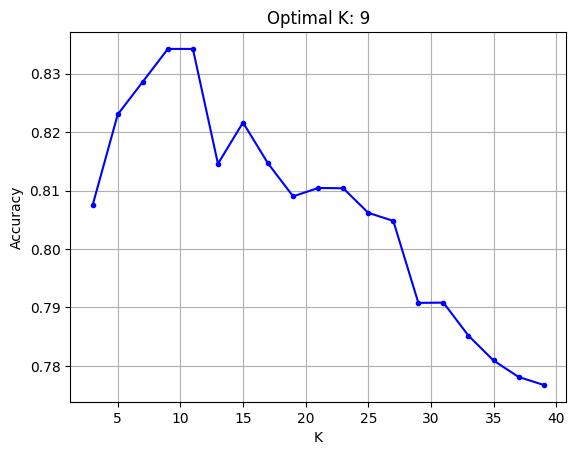

In [57]:
# plot average cross-validation score as a function of K
plt.plot(search.param_grid['n_neighbors'], search.cv_results_['mean_test_score'], 'b.-')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title(f'Optimal K: {K_opt}')
plt.grid();

In [58]:
print(f'Train acc = {knn.score(X_train, y_train):.2%}')
print(f'Test acc = {knn.score(X_test, y_test):.2%}')

Train acc = 85.96%
Test acc = 82.68%


**Explanation:**

We get two optimal values for K: 9 and 11. Here, we choose 9, because the plot shows that higher values for K seem to perform worse. On the other hand, the model with K = 9 performs less on the test set, but the accuracy is still acceptable.

Note that we scaled feature 'age' before splitting the dataset. According to machine learning best practices, we cannot use the test set to normalize the variables, so it should be done after splitting the dataset and only using the training set. However, here we take 100 as a maximum age, which is not derived from the training set, but a realistic upper bound based on common sense.

---